In [1]:
from lappy import *
import numpy as np
import matplotlib.pyplot as plt

# L-shaped domain

In [2]:
n_eigs = 25
n_basis = 120

data = np.load(f"l_shape_e{n_eigs}_n{n_basis}.npz")
eigs = data['eigs']
tensions = data['tensions']
relerr_est = data['relerr_est']

plt.semilogy(eigs, relerr_est, marker='o', linestyle='')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'relative error (estimated)')
plt.title("L-shaped domain eigenvalues: estimated relative error bound")
plt.show()

print(eigs)
print(relerr_est)

FileNotFoundError: [Errno 2] No such file or directory: 'l_shape_e25_n120.npz'

In [11]:
x = 1.0
h = 1e-14
print(np.abs(x-x*(1+h))/x)

9.992007221626409e-15


In [18]:
np.set_printoptions(precision=20)
repr(eigs)

'array([  9.639723844021946,  15.197251926454308,  19.739208802178716,\n        29.521481114144848,  31.912635957137752,  41.47450989021491 ,\n        44.94848778135119 ,  49.34802200544678 ,  49.34802200544678 ,\n        56.70960988738507 ,  65.37653570984583 ,  71.05775564851349 ,\n        71.57267968033655 ,  78.95683520871486 ,  89.30166835196012 ,\n        92.3069067630492  ,  97.38072264602184 ,  98.69604401089357 ,\n        98.69604401089357 , 101.60529408377867 , 112.36860922562566 ,\n       115.5201730946677  , 128.30485721416164 , 128.30485721416164 ,\n       130.11902885096785 ])'

In [12]:
print(x*(1+h))

1.00000000000001


In [28]:
ldom = geometry.L_shape()

# basis info
orders = [n_basis, 0, 0, 0, 0, 0]

# bdry and int pts
n_per_seg = n_basis
bdry_pts, bdry_normals = ldom.bdry_data(n_per_seg)[:2]
int_pts = ldom.int_pts(npts_rand=n_basis)

# solver
basis = FourierBesselBasis.from_domain(ldom, orders).to_normalized(bdry_pts + int_pts)
solver = MPSEigensolver(basis, bdry_pts, int_pts)

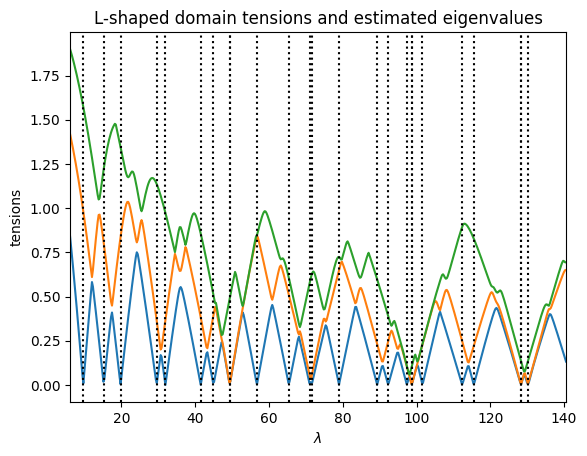

In [29]:
# plot tensions and estimated eigs
fig, ax = plt.subplots()
low = bounds.faber_krahn(ldom)
hi = asymp.weyl_est(n_eigs+1, ldom)
solver.plot_tensions(low, hi, 20*(n_eigs+1), 3, ax=ax)
for eig in eigs:
    ax.axvline(eig, linestyle=':', c='k')
plt.title("L-shaped domain tensions and estimated eigenvalues")
plt.xlabel(r"$\lambda$")
plt.ylabel("tensions")
plt.show()

# GWW domains

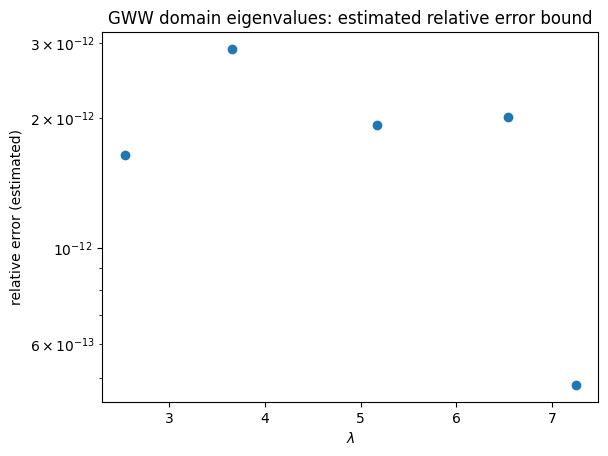

[2.537944   3.65550971 5.17555936 6.53755744 7.24807786]
[1.64565856e-12 2.89961050e-12 1.93308329e-12 2.01082526e-12
 4.80958964e-13]


In [19]:
n_eigs = 5
n_basis = 120

data = np.load(f"gww_e{n_eigs}_n{n_basis}.npz")
eigs = data['eigs']
tensions = data['tensions']
relerr_est = data['relerr_est']

plt.semilogy(eigs, relerr_est, marker='o', linestyle='')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'relative error (estimated)')
plt.title("GWW domain eigenvalues: estimated relative error bound")
plt.show()

print(eigs)
print(relerr_est)

In [23]:
gww = geometry.GWW1()

# basis info
orders = [0, n_basis, 0, n_basis, 0, 0, n_basis, n_basis]

# bdry and int pts
n_per_seg = n_basis
bdry_pts, bdry_normals = gww.bdry_data(n_per_seg)[:2]
int_pts = gww.int_pts(npts_rand=n_basis)

basis = FourierBesselBasis.from_domain(gww, orders).to_normalized(bdry_pts + int_pts)
solver = MPSEigensolver(basis, bdry_pts, int_pts, rtol=1e-12)

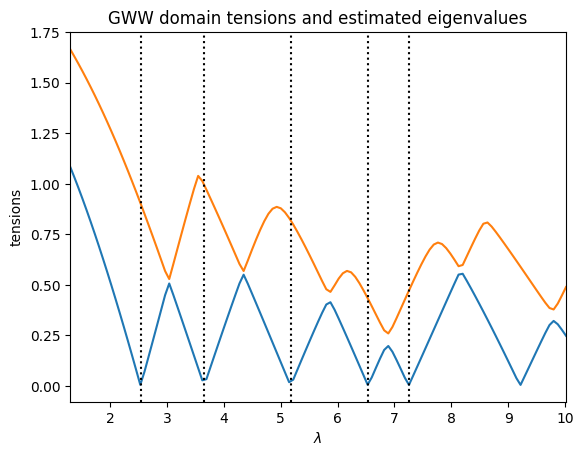

In [24]:
# plot tensions and estimated eigs
fig, ax = plt.subplots()
low = bounds.faber_krahn(gww)
hi = asymp.weyl_est(n_eigs+1, gww)
solver.plot_tensions(low, hi, 20*(n_eigs+1), 2, ax=ax)
for eig in eigs:
    ax.axvline(eig, linestyle=':', c='k')
plt.title("GWW domain tensions and estimated eigenvalues")
plt.xlabel(r"$\lambda$")
plt.ylabel("tensions")
plt.show()